In [295]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

import pandas as pd
import torch
import random
from torch import nn
from pathlib import Path

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from helper_functions import accuracy_fn

import matplotlib.pyplot as plt

print(
    f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}"
)

PyTorch version: 2.9.1
torchvision version: 0.24.1


In [253]:
device = "cpu"

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"

In [254]:
train_data = datasets.FashionMNIST(
    root="data",  # Where to save downloaded data
    train=True,  # Download train set
    download=True,  # Download dataset to disk
    transform=ToTensor(),  # Transform PIL images to Torch tensors
    # This property defaults to None
    target_transform=None,  # Leave original labels
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [255]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [256]:
image.shape

torch.Size([1, 28, 28])

In [257]:
(
    len(train_data.data),
    len(train_data.targets),
    len(test_data.data),
    len(test_data.targets),
)

(60000, 60000, 10000, 10000)

In [258]:
class_names = train_data.classes
class_names  # Our problem is multi-class classification as we have 10 target classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Ankle boot')

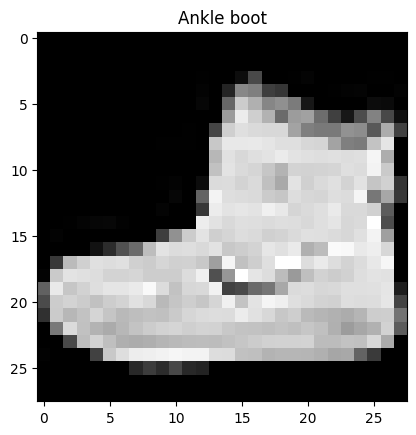

In [259]:
print(f"Image shape: {image.shape}")
plt.imshow(
    image.squeeze(), cmap="gray"
)  # .squeeze() here removes unneccessary color dimension from the image tensor
plt.title(class_names[label])

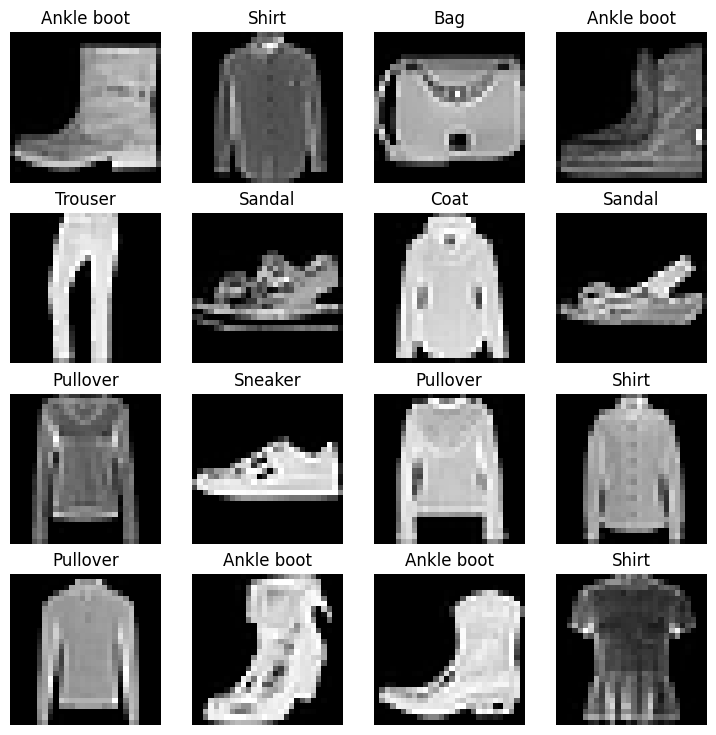

In [260]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))

rows, cols = 4, 4

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]

    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

32 batch size is a good choice for most problems. But still it's a hyperparameter.

In [261]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x34206bfb0>, <torch.utils.data.dataloader.DataLoader object at 0x1111e1c40>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [262]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


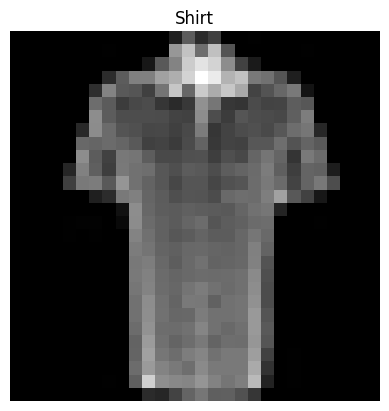

In [263]:
# Show a sample
torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off")

print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")


In [264]:
flatten_model = nn.Flatten()  # Flatten layer takes shape [color_channels, height, width] and convert it to [color_channels, height * width]

x = train_features_batch[0]
output = flatten_model(x)

print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height * width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height * width]


In [265]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),  # Convert width x height into a feature version
            nn.Linear(
                in_features=input_shape, out_features=hidden_units
            ),  # in_features = number of features in a data sample (784 pixels)
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )

    def forward(self, x):
        return self.layer_stack(x)

In [266]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names),
)

model_0.to("cpu")  # Keep the model on CPU

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [267]:
loss_fn = nn.CrossEntropyLoss()  # Use cross entropy loss for classification
optimizer = torch.optim.SGD(
    params=model_0.parameters(), lr=0.1
)  # Use stochastic gradient descent as an optimizer

In [268]:
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

A few things to note
- Our data is given in batches, thus calculated metrics will describe entire batches
- 

In [269]:
torch.manual_seed(42)

epochs = 3
train_time_start_on_cpu = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    # Calculate loss for the whole dataset (not a single batch)
    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()  # this sets the model in training mode

        # Evaluate
        train_pred = model_0(X)

        # Figure out the fit quality (or rather loss, how bad are we)
        loss = loss_fn(train_pred, y)
        train_loss += loss

        optimizer.zero_grad()  # Reset the gradient from the previous run
        loss.backward()  # Run gradient descent
        optimizer.step()  # Optimizer step

        if batch % 400 == 0:
            print(f"Looked at {batch + len(X)}/{len(train_dataloader.dataset)} samples")

    # Figure out average train_loss per batch per epoch
    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model_0.eval()

    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)  # Forward pass
            test_loss += loss_fn(test_pred, y)  # Calculate the loss
            test_acc += accuracy_fn(
                y_true=y, y_pred=test_pred.argmax(dim=1)
            )  # Calculate the acc

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(
        f"\n Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n"
    )


train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(
    start=train_time_start_on_cpu,
    end=train_time_end_on_cpu,
    device=str(next(model_0.parameters()).device),
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 32/60000 samples
Looked at 432/60000 samples
Looked at 832/60000 samples
Looked at 1232/60000 samples
Looked at 1632/60000 samples


 33%|███▎      | 1/3 [00:01<00:03,  1.60s/it]


 Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Looked at 32/60000 samples
Looked at 432/60000 samples
Looked at 832/60000 samples
Looked at 1232/60000 samples
Looked at 1632/60000 samples


 67%|██████▋   | 2/3 [00:03<00:01,  1.60s/it]


 Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Looked at 32/60000 samples
Looked at 432/60000 samples
Looked at 832/60000 samples
Looked at 1232/60000 samples
Looked at 1632/60000 samples


100%|██████████| 3/3 [00:04<00:00,  1.62s/it]


 Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu: 4.868 seconds


In [270]:
torch.manual_seed(42)


def eval_model(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device,
):
    """Returns a dict containing the results of model predicting on data_loader."""

    loss, acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)

            # Calculate loss and acc per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss.item(),
        "model_acc": acc,
    }

In [271]:
model_0_results = eval_model(
    model=model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device="cpu",
)

model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [272]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),  # Flatten inputs into a single vector
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),  # Introduce nonlinearity
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU(),  # Introduce nonlinearity
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [273]:
torch.manual_seed(42)

model_1 = FashionMNISTModelV1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names),  # number of output classes desired
).to(device)  # send model to GPU if it's available

next(model_1.parameters()).device  # check model device

device(type='mps', index=0)

In [274]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [275]:
def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device,
):
    train_loss, train_acc = 0, 0
    model.to(device)

    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        train_pred = model(X)

        # 2. Calculate the loss
        loss = loss_fn(train_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=train_pred.argmax(dim=1))

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


def test_step(
    data_loader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device,
):
    test_loss, test_acc = 0, 0

    model.to(device)
    model.eval()  # Put model in eval node

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and acc
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [276]:
torch.manual_seed(42)

epochs = 3
train_time_start_on_gpu = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    train_step(
        data_loader=train_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
    )

    test_step(
        data_loader=test_dataloader,
        model=model_1,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
    )

train_time_end_on_gpu = timer()

total_train_time_model_1 = print_train_time(
    start=train_time_start_on_gpu,
    end=train_time_end_on_gpu,
    device=device,
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 1.09199 | Train accuracy: 61.34%


 33%|███▎      | 1/3 [00:04<00:09,  4.73s/it]

Test loss: 0.95636 | Test accuracy: 65.00%

Epoch: 1
-------
Train loss: 0.78097 | Train accuracy: 71.94%


 67%|██████▋   | 2/3 [00:09<00:04,  4.46s/it]

Test loss: 0.72611 | Test accuracy: 73.99%

Epoch: 2
-------
Train loss: 0.67040 | Train accuracy: 75.94%


100%|██████████| 3/3 [00:13<00:00,  4.46s/it]

Test loss: 0.69007 | Test accuracy: 74.81%

Train time on mps: 13.367 seconds


In [277]:
torch.manual_seed(42)

model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
)

model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6900655031204224,
 'model_acc': 74.810303514377}

In [278]:
class FashionMNISTModelV2(nn.Module):
    """
    This model copies tinyVGG model architecture
    https://poloclub.github.io/cnn-explainer/
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,  # Size of the square that's going over the image
                stride=1,  # default value
                padding=1,  # 1 is a specific padding size
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,  # By default stride has the same value as kernel_size
            ),
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # in_features value comes from a fact that each layer of our network
            # compresses and changes the shape of our input data
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)

        x = self.block_2(x)
        # print(x.shape)

        x = self.classifier(x)
        # print(x.shape)

        return x


torch.manual_seed(42)

model_2 = FashionMNISTModelV2(
    input_shape=1, hidden_units=10, output_shape=len(class_names)
).to(device)

model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [279]:
torch.manual_seed(42)

# Generate random numbers with the same size as our batch
images = torch.rand(size=(32, 3, 64, 64))
test_image = images[0]

print(
    f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]"
)
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[0.8823, 0.9150, 0.3829,  ..., 0.1587, 0.6542, 0.3278],
         [0.6532, 0.3958, 0.9147,  ..., 0.2083, 0.3289, 0.1054],
         [0.9192, 0.4008, 0.9302,  ..., 0.5535, 0.4117, 0.3510],
         ...,
         [0.1457, 0.1499, 0.3298,  ..., 0.9624, 0.6400, 0.7409],
         [0.1709, 0.5797, 0.6340,  ..., 0.6885, 0.2405, 0.5956],
         [0.9199, 0.1247, 0.3573,  ..., 0.6752, 0.2058, 0.5027]],

        [[0.1458, 0.9024, 0.9217,  ..., 0.1868, 0.6352, 0.8431],
         [0.9549, 0.4435, 0.6924,  ..., 0.1168, 0.7160, 0.5462],
         [0.1616, 0.1054, 0.8614,  ..., 0.4531, 0.4736, 0.9448],
         ...,
         [0.4309, 0.3986, 0.1907,  ..., 0.9444, 0.2848, 0.3776],
         [0.7948, 0.6855, 0.1009,  ..., 0.6147, 0.7747, 0.2323],
         [0.5840, 0.9795, 0.3277,  ..., 0.3549, 0.1263,

- `in_channels (int)` Number of channels in the input image
- `out_channels (int)` Number of channels produced by the convolution
- `kernel_size (int or tuple)` Size of the convolving kernel / filter (the square that get's overlapped with the image)
- `stride (int or tuple, optional)` How big of a step the convolving kernel takes at a time. Defaults to 1.
- `padding (int, tuple, str)` Padding added to all four sides of input. Defaults to 0.

In [280]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [281]:
torch.manual_seed(42)

train_time_start_model2 = timer()
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n-------")

    train_step(
        data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device,
    )

    test_step(
        data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device,
    )

train_time_end_module2 = timer()
total_train_time_model_2 = print_train_time(
    start=train_time_start_model2, end=train_time_end_module2, device=device
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 0
-------
Train loss: 0.59093 | Train accuracy: 78.58%


 33%|███▎      | 1/3 [00:06<00:13,  6.57s/it]

Test loss: 0.39339 | Test accuracy: 85.64%

Epoch 1
-------
Train loss: 0.36547 | Train accuracy: 86.80%


 67%|██████▋   | 2/3 [00:13<00:06,  6.66s/it]

Test loss: 0.35461 | Test accuracy: 86.92%

Epoch 2
-------
Train loss: 0.32907 | Train accuracy: 88.08%


100%|██████████| 3/3 [00:19<00:00,  6.60s/it]

Test loss: 0.32918 | Test accuracy: 87.82%

Train time on mps: 19.790 seconds


In [282]:
# Get model_2 results
model_2_results = eval_model(
    model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_2_results


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3291807472705841,
 'model_acc': 87.81948881789137}

In [283]:
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.690066,74.810304
2,FashionMNISTModelV2,0.329181,87.819489


In [284]:
compare_results["training_time"] = [
    total_train_time_model_0,
    total_train_time_model_1,
    total_train_time_model_2,
]

compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,4.867692
1,FashionMNISTModelV1,0.690066,74.810304,13.366926
2,FashionMNISTModelV2,0.329181,87.819489,19.790278


Text(0, 0.5, 'model')

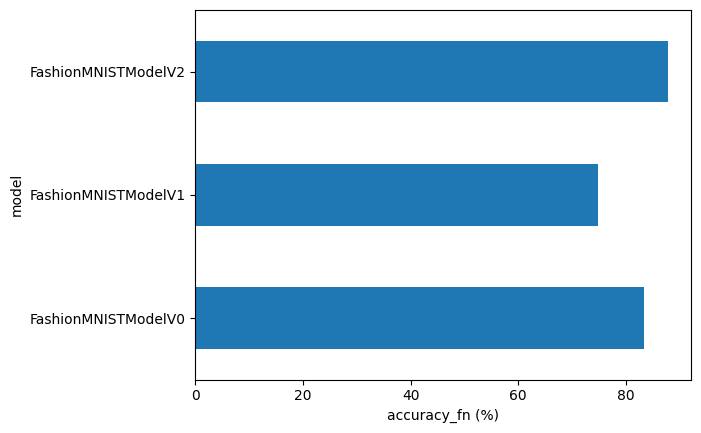

In [285]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy_fn (%)")
plt.ylabel("model")

In [286]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device)

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            # Get pred_probs off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Turn list into a tensor
    return torch.stack(pred_probs)

In [287]:
random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(
    f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})"
)

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [288]:
pred_probs = make_predictions(model=model_2, data=test_samples)
pred_probs[:2]

tensor([[1.1463e-07, 3.3334e-09, 1.2339e-08, 2.0630e-07, 3.0217e-09, 9.9997e-01,
         3.0559e-07, 4.5058e-06, 9.3164e-06, 1.2467e-05],
        [1.2419e-01, 4.4711e-01, 5.2430e-03, 2.1692e-01, 5.5287e-02, 1.4861e-04,
         1.4886e-01, 5.5454e-04, 1.4347e-03, 2.5677e-04]])

In [289]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [290]:
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

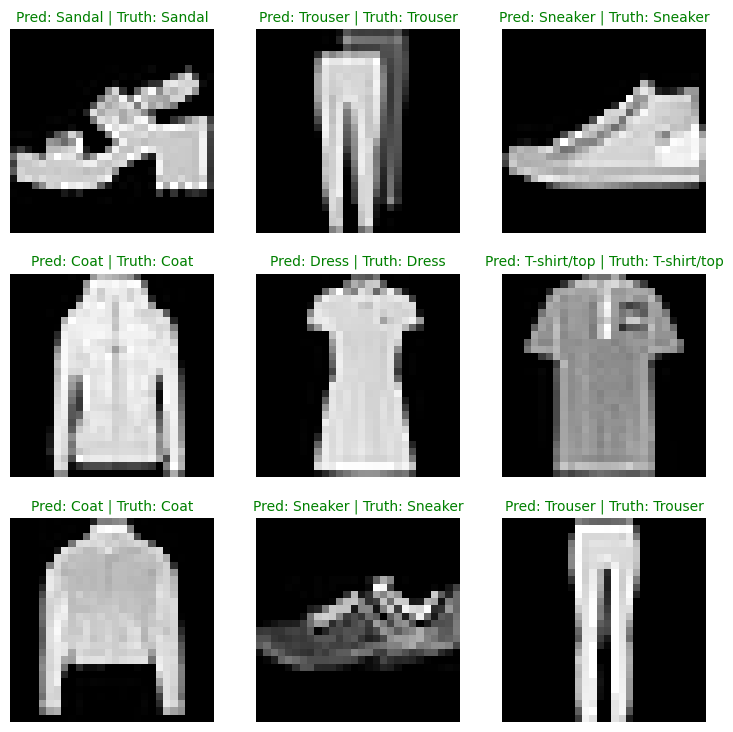

In [291]:
plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(sample.squeeze(), cmap="gray")

    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]

    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c="r")

    plt.axis(False)

In [292]:
y_preds = []
model_2.eval()

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        y_logit = model_2(X)  # Forward pass
        y_pred = torch.softmax(y_logit, dim=1).argmax(
            dim=1
        )  # logits -> prediction probabilities -> prediction labels
        y_preds.append(y_pred.cpu())

# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions: 100%|██████████| 313/313 [00:00<00:00, 558.79it/s]


In [293]:
# This sets up the confusion matrix to compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

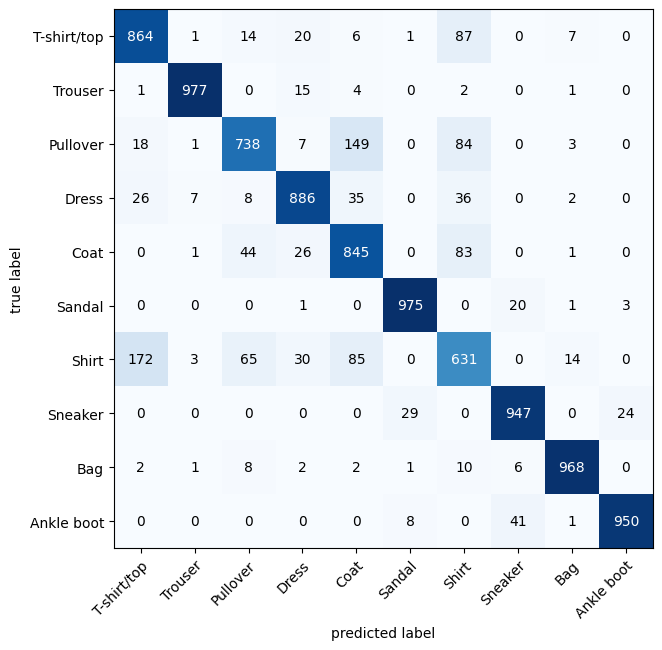

In [294]:
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),  # matplotlib likes working with numpy
    class_names=class_names,  # turn the row and column labels into class names
    figsize=(10, 7),
)

## Saving the model

In [297]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")

torch.save(
    obj=model_2.state_dict(),  # Saving only the learned parameters
    f=MODEL_SAVE_PATH,
)

Saving model to: models/03_pytorch_computer_vision_model_2.pth


## Loading the model

In [299]:
loaded_model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=10)
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2 = loaded_model_2.to(device)

loaded_model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [300]:
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
)

loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3291807472705841,
 'model_acc': 87.81948881789137}